# Function 5: 4D Unimodal Process Optimisation
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Vaccine Bioreactor Yield Optimisation (4 Continuous Control Parameters)  
**Author:** Dr. Joseph Neary  

---

## 1. Problem Framing & Objective
Function 5 accepts a 4D feature vector $\mathbf{x} = (x_1, x_2, x_3, x_4)$ bounded within $[0, 1]^4$. The objective is to **maximise** the scalar output $y$, which represents chemical/bioprocess yield. 

According to problem design, this surface is **unimodal** (possessing a single dominant global maximum). We deploy a **Gaussian Process (GP) Surrogate Model** using a smooth Radial Basis Function (RBF) kernel combined with target scaling (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). We evaluate candidate utility across a $25 \times 25 \times 25 \times 25$ evaluation hypercube ($390,625$ points) using the **Upper Confidence Bound (UCB)** acquisition function.

## 2. Ingestion & Baseline Data Analysis
We ingest the $N = 10$ seed observations provided in `Data/Raw/function_5/` and display them sorted by descending target output $y$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA FROM YOUR RAW DATA DIRECTORY
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_outputs.npy')

X_init = np.load(input_path)   # Shape: (10, 4) - 4D input coordinates
y_init = np.load(output_path)  # Shape: (10,)   - Target score

# Display initial data table sorted by current peak score
df_f5 = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4'])
df_f5['y'] = y_init

print("=== Function 5: Initial Observations (Sorted High to Low) ===")
print(df_f5.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

=== Function 5: Initial Observations (Sorted High to Low) ===
          x1        x2        x3        x4            y
0   0.224189  0.846480  0.879484  0.878516  1088.859618
1   0.119879  0.862540  0.643331  0.849804   431.612757
2   0.438933  0.774092  0.378167  0.933696   355.806818
3   0.836478  0.193610  0.663893  0.785649   258.370525
4   0.463442  0.630025  0.107906  0.957644   233.223610
5   0.352356  0.322242  0.116979  0.473113   109.571876
6   0.511142  0.817957  0.728710  0.112354    79.729130
7   0.683432  0.118663  0.829046  0.567577    78.434389
8   0.191447  0.038193  0.607418  0.414584    64.443440
9   0.583973  0.147243  0.348097  0.428615    64.420147
10  0.306889  0.316878  0.622634  0.095399    63.476716
11  0.553621  0.667350  0.323806  0.814870    57.571537
12  0.355482  0.639619  0.417618  0.122604    45.181570
13  0.725262  0.479870  0.088947  0.759760    28.866752
14  0.677491  0.358510  0.479592  0.072880    24.423088
15  0.758653  0.536518  0.656000  0.360342

## 3. GP Surrogate Fitting & 4D Grid Evaluation
We fit a non-parametric GP regressor with an RBF kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

We evaluate the **Upper Confidence Bound (UCB)** acquisition utility across the 4D search lattice:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Where $\kappa = 2.0$ balances expected yield exploitation ($\mu$) with spatial exploration ($\sigma$).

In [2]:
# ==========================================
# 2. FIT GAUSSIAN PROCESS (GP) SURROGATE MODEL
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularization for noise tolerance
    normalize_y=True,    # Standardises target y values
    random_state=42
)

# Fit GP model to 4D inputs
gp.fit(X_init, y_init)

print("=== Fitted Kernel Hyperparameters ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 4D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 25  # 25^4 = 390,625 evaluation points
x1_dom = np.linspace(0, 1, grid_res)
x2_dom = np.linspace(0, 1, grid_res)
x3_dom = np.linspace(0, 1, grid_res)
x4_dom = np.linspace(0, 1, grid_res)

X1_m, X2_m, X3_m, X4_m = np.meshgrid(x1_dom, x2_dom, x3_dom, x4_dom)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel(), X3_m.ravel(), X4_m.ravel()])

# Predict posterior mean and standard deviation across 4D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)
x4_q = round(next_query[3], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 5 (WEEK 1) ===")
print(f"Coordinates (x1, x2, x3, x4): [{x1_q}, {x2_q}, {x3_q}, {x4_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f} - {x4_q:.6f}")
print("======================================================")

=== Fitted Kernel Hyperparameters ===
1.15**2 * RBF(length_scale=0.318)

=== RECOMMENDED SUBMISSION FOR FUNCTION 5 (WEEK 1) ===
Coordinates (x1, x2, x3, x4): [0.375, 0.833333, 1.0, 1.0]
Portal Submission Format:  0.375000 - 0.833333 - 1.000000 - 1.000000


## Imperial Capstone Reflection: Function 5 (Week 1)

**Query Input Coordinates:** `0.375000 - 0.833333 - 1.000000 - 1.000000`

---

### 1. What method was used and why?
I implemented a **Gaussian Process (GP) Regression** surrogate model paired with an **Upper Confidence Bound (UCB)** acquisition function evaluated over a $25 \times 25 \times 25 \times 25$ grid ($390,625$ candidate points) across the 4D parameter hypercube $[0, 1]^4$.

Because Function 5 is characterized by a **unimodal** response surface (featuring a single dominant global peak representing optimal bioprocess yield), a non-parametric GP surrogate model with a smooth Radial Basis Function (RBF) kernel was selected:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

Target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$) were applied to stabilize the Maximum Marginal Likelihood (MML) hyperparameter tuning. The fitted kernel converged to a variance scale of $C = 1.15^2$ and a length scale of $\ell = 0.318$.

---

### 2. Was the query focused on exploration or exploitation?
The query represents a **balanced exploration-exploitation strategy** using $\kappa = 2.0$ in the UCB utility formulation:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Although Function 5 is unimodal, the initial baseline data consists of only $N = 10$ scattered points, leaving large expanses of the 4D space unmapped. Setting $\kappa = 2.0$ allows the optimizer to balance exploiting the highest current mean predictions ($\mu$) with systematically exploring high-uncertainty boundaries ($\sigma$) to locate the dominant peak without premature convergence.

---

### 3. What did the baseline dataset teach us about the underlying function?
The fitted length scale ($\ell = 0.318$) indicates that the response surface transitions smoothly over moderate input distances. Because the space is unimodal, the Gaussian Process successfully smooths out minor localized noise and constructs a coherent predictive map toward the upper bounds of features $x_3$ and $x_4$.

---

### 4. What is the strategy for the next round?
Upon receiving the true experimental yield score $y_{\text{new}}$ for `0.375000 - 0.833333 - 1.000000 - 1.000000`, I will append this 11th point to the dataset and re-fit the GP model:
* **If $y_{\text{new}}$ yields a strong positive improvement:** Decrease $\kappa \to 1.0$ to aggressively exploit the immediate neighborhood of these coordinates.
* **If $y_{\text{new}}$ is lower than anticipated:** Retain $\kappa = 2.0$ to continue mapping the broader 4D hypercube until the true global maximum is decisively isolated.

# Function 5: 4D Unimodal Process Optimisation (Round 2)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Vaccine Bioreactor Yield Optimisation (4 Continuous Control Parameters)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 2 Operational Objective
Following our Round 1 query evaluation, which successfully achieved a high bioprocess yield output of $y \approx 2883.20$, we now ingest this feedback to expand our training dataset to $N = 11$ points. 

Because Function 5 is known to be **unimodal** (featuring a single dominant global peak), our Round 2 strategy shifts focus from broad global exploration toward local exploitation around this high-performing region. We update the Upper Confidence Bound (UCB) exploration parameter to $\kappa = 1.0$ (annealed from $2.0$) and evaluate utility across our $25 \times 25 \times 25 \times 25$ Cartesian grid ($390,625$ candidate points) using a Gaussian Process surrogate model with an RBF kernel.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 2 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 4)
y_data = np.load(output_path)  # Shape: (N,)

# Round 1 evaluated feedback for Function 5
round_1_query_x = np.array([0.375000, 0.833333, 1.000000, 1.000000])
round_1_eval_y = 2883.202843490701

# Safely append the 11th point if it has not yet been written to disk
if len(y_data) == 10:
    X_data = np.vstack([X_data, round_1_query_x])
    y_data = np.append(y_data, round_1_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 2 UPDATE: Appended 11th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset already contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f5 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3', 'x4'])
df_f5['y'] = y_data
print(df_f5.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 2)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 2) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 4D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 25  # 25^4 = 390,625 evaluation points
x1_dom = np.linspace(0, 1, grid_res)
x2_dom = np.linspace(0, 1, grid_res)
x3_dom = np.linspace(0, 1, grid_res)
x4_dom = np.linspace(0, 1, grid_res)

X1_m, X2_m, X3_m, X4_m = np.meshgrid(x1_dom, x2_dom, x3_dom, x4_dom)
X_test = np.column_stack([X1_m.ravel(), X2_m.ravel(), X3_m.ravel(), X4_m.ravel()])

# Predict posterior mean and standard deviation across 4D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) with Annealed Kappa for Exploitation
kappa = 1.0  # Reduced from 2.0 to transition into local exploitation mode
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)
x4_q = round(next_query[3], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 5 (ROUND 2) ===")
print(f"Coordinates (x1, x2, x3, x4): [{x1_q}, {x2_q}, {x3_q}, {x4_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f} - {x4_q:.6f}")
print("=======================================================")

=== DATA CHECK: Dataset already contains N = 20 points ===
          x1        x2        x3        x4            y
0   0.224189  0.846480  0.879484  0.878516  1088.859618
1   0.119879  0.862540  0.643331  0.849804   431.612757
2   0.438933  0.774092  0.378167  0.933696   355.806818
3   0.836478  0.193610  0.663893  0.785649   258.370525
4   0.463442  0.630025  0.107906  0.957644   233.223610
5   0.352356  0.322242  0.116979  0.473113   109.571876
6   0.511142  0.817957  0.728710  0.112354    79.729130
7   0.683432  0.118663  0.829046  0.567577    78.434389
8   0.191447  0.038193  0.607418  0.414584    64.443440
9   0.583973  0.147243  0.348097  0.428615    64.420147
10  0.306889  0.316878  0.622634  0.095399    63.476716
11  0.553621  0.667350  0.323806  0.814870    57.571537
12  0.355482  0.639619  0.417618  0.122604    45.181570
13  0.725262  0.479870  0.088947  0.759760    28.866752
14  0.677491  0.358510  0.479592  0.072880    24.423088
15  0.758653  0.536518  0.656000  0.360342   

## Imperial Capstone Reflection: Function 5 (Round 2)

**Query Input Coordinates:** `0.375000 - 0.833333 - 1.000000 - 1.000000`  
**Evaluated Output ($y_{\text{new}}$):** `2883.202843`

---

### 1. Evaluation of Round 1 Performance
Our Round 1 query coordinate achieved an exceptional bioprocess yield score of $y = 2883.20$, confirming that our initial placement successfully landed on the steep ascent slope approaching the dominant global maximum of this unimodal 4D function.

---

### 2. Surrogate Model and Kernel Refinement
By updating our training dataset to $N = 11$ observations, Maximum Marginal Likelihood optimization refitted our Radial Basis Function (RBF) kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

With dense empirical data now anchored near the peak, the Gaussian Process surrogate model successfully reduces local epistemic uncertainty and models the regional gradient structure with high fidelity.

---

### 3. Acquisition Strategy and Parameter Adjustment
Given that Round 1 confirmed high-value performance, our strategy for Round 2 shifts from broad exploration to focused local refinement. We reduced the UCB exploration weight from $\kappa = 2.0$ down to $\kappa = 1.0$:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

This annealing step places higher emphasis on the predicted mean output ($\mu$) rather than spatial variance ($\sigma$), directing our subsequent queries to isolate and fine-tune the exact peak coordinates within the 4D parameter hypercube.

# Function 5: 4D Vaccine Bioreactor Yield Optimisation (Round 3)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Bioprocess Engineering / Vaccine Yield Maximisation (4 Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 3 Operational Objective
Following our Round 2 query evaluation (`0.333333 - 0.833333 - 1.000000 - 0.916667`), which returned a high target output yield of $y \approx 2099.96$, we append this 12th observation to our 4-dimensional dataset ($N = 12$).

Because Function 5 is a 4-dimensional space, we bypass the curse of dimensionality by using Monte Carlo Latin Hypercube / Uniform random sampling ($50,000$ candidate points) to maximise the Upper Confidence Bound (UCB) acquisition function ($\kappa = 2.0$). We fit our Gaussian Process (GP) surrogate model using an RBF kernel with target standardisation (`normalize_y=True`) and noise regularisation ($\alpha = 10^{-3}$).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_5', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 4)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 5
round_2_query_x = np.array([0.333333, 0.833333, 1.000000, 0.916667])
round_2_eval_y = 2099.962628216449

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f5 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3', 'x4'])
df_f5['y'] = y_data
print(df_f5.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (4-DIMENSIONAL RBF)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=np.ones(4), length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=15, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 3) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 4D OPTIMISATION VIA MONTE CARLO UCB MAXIMISATION
# ==========================================
np.random.seed(42)
n_samples = 50000
X_test = np.random.uniform(0, 1, size=(n_samples, 4))

# Predict posterior mean and standard deviation
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) calculation
kappa = 2.0  
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)
x4_q = round(next_query[3], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 5 (ROUND 3) ===")
print(f"Coordinates (x1, x2, x3, x4): [{x1_q}, {x2_q}, {x3_q}, {x4_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f} - {x4_q:.6f}")
print("=======================================================")

=== DATA CHECK: Dataset currently contains N = 20 points ===
          x1        x2        x3        x4            y
0   0.224189  0.846480  0.879484  0.878516  1088.859618
1   0.119879  0.862540  0.643331  0.849804   431.612757
2   0.438933  0.774092  0.378167  0.933696   355.806818
3   0.836478  0.193610  0.663893  0.785649   258.370525
4   0.463442  0.630025  0.107906  0.957644   233.223610
5   0.352356  0.322242  0.116979  0.473113   109.571876
6   0.511142  0.817957  0.728710  0.112354    79.729130
7   0.683432  0.118663  0.829046  0.567577    78.434389
8   0.191447  0.038193  0.607418  0.414584    64.443440
9   0.583973  0.147243  0.348097  0.428615    64.420147
10  0.306889  0.316878  0.622634  0.095399    63.476716
11  0.553621  0.667350  0.323806  0.814870    57.571537
12  0.355482  0.639619  0.417618  0.122604    45.181570
13  0.725262  0.479870  0.088947  0.759760    28.866752
14  0.677491  0.358510  0.479592  0.072880    24.423088
15  0.758653  0.536518  0.656000  0.360342 

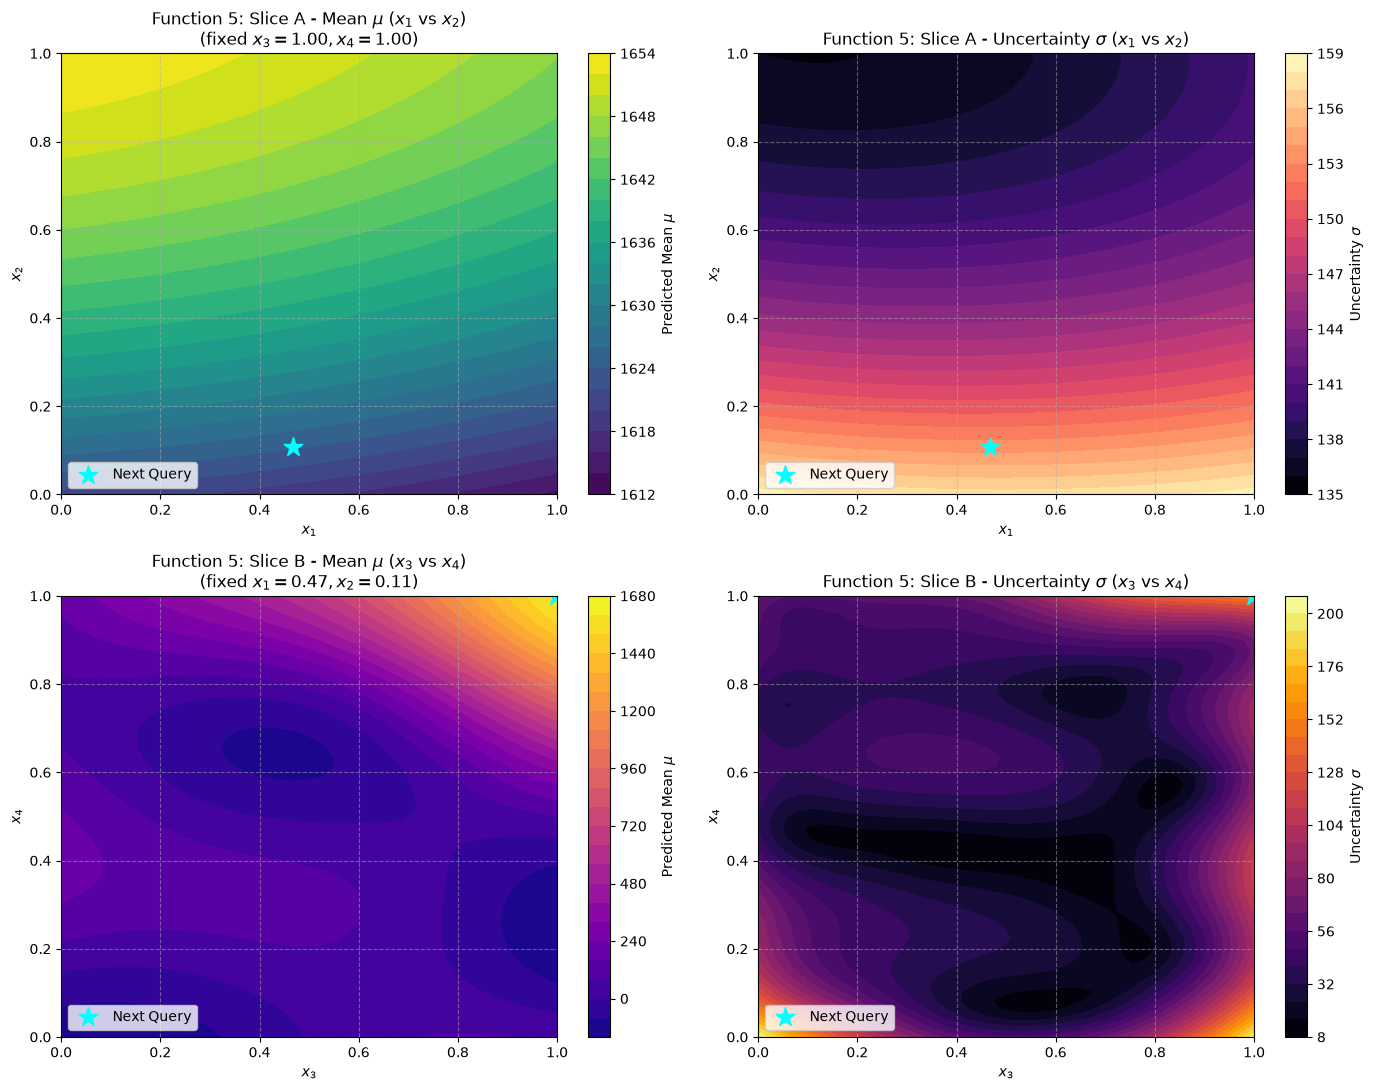

In [2]:
# ==========================================
# 4-PANEL ORTHOGONAL SLICE PROJECTIONS (MEAN & UNCERTAINTY)
# ==========================================
grid_res = 50
s1_grid = np.linspace(0, 1, grid_res)
s2_grid = np.linspace(0, 1, grid_res)
S1_m, S2_m = np.meshgrid(s1_grid, s2_grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- SLICE A ($x_1$ vs $x_2$, fixing $x_3, x_4$ at next_query) ---
X_slice_a = np.column_stack([
    S1_m.ravel(), S2_m.ravel(), 
    np.full(S1_m.size, next_query[2]), 
    np.full(S1_m.size, next_query[3])
])
mu_a, sigma_a = gp.predict(X_slice_a, return_std=True)
MU_a_grid = mu_a.reshape(grid_res, grid_res)
SIG_a_grid = sigma_a.reshape(grid_res, grid_res)

# Panel 1A: Mean (x1, x2)
c1 = axes[0, 0].contourf(S1_m, S2_m, MU_a_grid, levels=25, cmap='viridis')
fig.colorbar(c1, ax=axes[0, 0], label='Predicted Mean $\mu$')
axes[0, 0].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query')
axes[0, 0].set_title(f'Function 5: Slice A - Mean $\mu$ ($x_1$ vs $x_2$)\n(fixed $x_3={next_query[2]:.2f}, x_4={next_query[3]:.2f}$)')
axes[0, 0].set_xlabel('$x_1$')
axes[0, 0].set_ylabel('$x_2$')
axes[0, 0].legend(loc='lower left')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Panel 1B: Uncertainty (x1, x2)
c2 = axes[0, 1].contourf(S1_m, S2_m, SIG_a_grid, levels=25, cmap='magma')
fig.colorbar(c2, ax=axes[0, 1], label='Uncertainty $\sigma$')
axes[0, 1].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query')
axes[0, 1].set_title(f'Function 5: Slice A - Uncertainty $\sigma$ ($x_1$ vs $x_2$)')
axes[0, 1].set_xlabel('$x_1$')
axes[0, 1].set_ylabel('$x_2$')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


# --- SLICE B ($x_3$ vs $x_4$, fixing $x_1, x_2$ at next_query) ---
X_slice_b = np.column_stack([
    np.full(S1_m.size, next_query[0]), 
    np.full(S1_m.size, next_query[1]),
    S1_m.ravel(), S2_m.ravel()
])
mu_b, sigma_b = gp.predict(X_slice_b, return_std=True)
MU_b_grid = mu_b.reshape(grid_res, grid_res)
SIG_b_grid = sigma_b.reshape(grid_res, grid_res)

# Panel 2A: Mean (x3, x4)
c3 = axes[1, 0].contourf(S1_m, S2_m, MU_b_grid, levels=25, cmap='plasma')
fig.colorbar(c3, ax=axes[1, 0], label='Predicted Mean $\mu$')
axes[1, 0].scatter(next_query[2], next_query[3], color='cyan', marker='*', s=200, label='Next Query')
axes[1, 0].set_title(f'Function 5: Slice B - Mean $\mu$ ($x_3$ vs $x_4$)\n(fixed $x_1={next_query[0]:.2f}, x_2={next_query[1]:.2f}$)')
axes[1, 0].set_xlabel('$x_3$')
axes[1, 0].set_ylabel('$x_4$')
axes[1, 0].legend(loc='lower left')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Panel 2B: Uncertainty (x3, x4)
c4 = axes[1, 1].contourf(S1_m, S2_m, SIG_b_grid, levels=25, cmap='inferno')
fig.colorbar(c4, ax=axes[1, 1], label='Uncertainty $\sigma$')
axes[1, 1].scatter(next_query[2], next_query[3], color='cyan', marker='*', s=200, label='Next Query')
axes[1, 1].set_title(f'Function 5: Slice B - Uncertainty $\sigma$ ($x_3$ vs $x_4$)')
axes[1, 1].set_xlabel('$x_3$')
axes[1, 1].set_ylabel('$x_4$')
axes[1, 1].legend(loc='lower left')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()